
--- LEVEL 1: VISION ENSEMBLE EVALUATION ---
Quadratic Weighted Kappa (QWK): 0.9234

Classification Report:
              precision    recall  f1-score   support

           0     0.8918    0.9726    0.9304     55162
           1     0.9086    0.7783    0.8384     18470
           2     0.8707    0.7861    0.8262     24198
           3     0.9552    0.9585    0.9569      7936
           4     0.9430    0.9408    0.9419      9475

    accuracy                         0.8987    115241
   macro avg     0.9139    0.8873    0.8988    115241
weighted avg     0.8986    0.8987    0.8966    115241



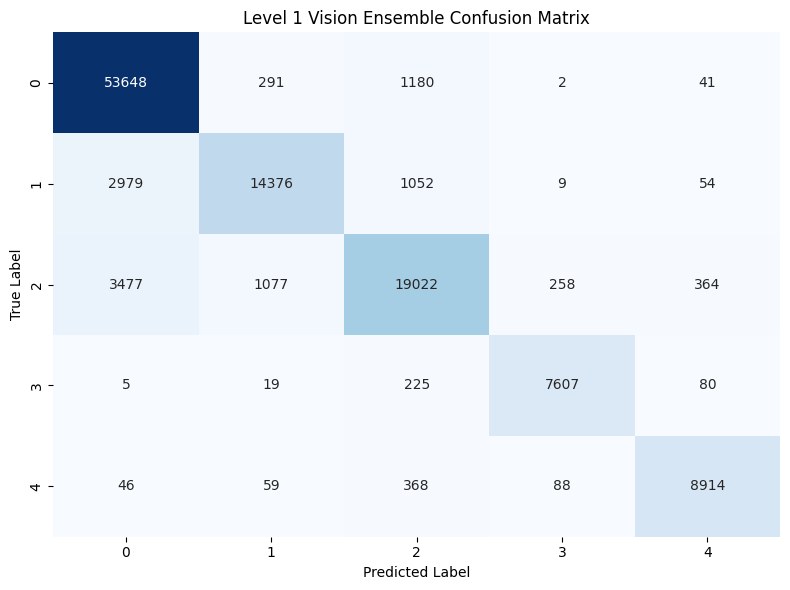

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score, confusion_matrix, classification_report
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Base Model Predictions
df_base = pd.read_csv("/kaggle/input/notebooks/alokdevforge/dr-research-pt-1-convnext-5-fold-cv/oof_predictions_convnext.csv")
df_swin = pd.read_csv("/kaggle/input/notebooks/amrriit/dr-research-pt-2-swin-transformer-5-fold-98ba0d/oof_predictions_swin_tiny.csv")
df_effnet = pd.read_csv("/kaggle/input/notebooks/masteraashish/dr-research-pt-3-efficientnet-5-fold-cv/oof_predictions_tf_efficientnetv2_s.csv")

cols_to_use_swin = [c for c in df_swin.columns if 'swin' in c]
df_base[cols_to_use_swin] = df_swin[cols_to_use_swin]

cols_to_use_effnet = [c for c in df_effnet.columns if 'efficientnet' in c]
df_base[cols_to_use_effnet] = df_effnet[cols_to_use_effnet]

df_base['image_id'] = df_base['image_path'].apply(lambda x: x.split('/')[-1].split('.')[0])

vision_feature_cols = [c for c in df_base.columns if 'prob' in c]
target_col = 'label'

oof_preds_vision = np.zeros((len(df_base), 5))
oof_labels_vision = np.zeros(len(df_base))

# 2. Train the Level 1 Meta-Model
for fold in range(5):
    train_idx = df_base['fold'] != fold
    val_idx = df_base['fold'] == fold
    
    X_train = df_base.loc[train_idx, vision_feature_cols]
    y_train = df_base.loc[train_idx, target_col]
    X_val = df_base.loc[val_idx, vision_feature_cols]
    y_val = df_base.loc[val_idx, target_col]
    
    model_vision = xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=5,
        eval_metric='mlogloss',
        max_depth=3,
        learning_rate=0.05,
        n_estimators=200,
        random_state=42
    )
    
    model_vision.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    
    val_preds_proba = model_vision.predict_proba(X_val)
    oof_preds_vision[val_idx] = val_preds_proba
    oof_labels_vision[val_idx] = model_vision.predict(X_val)

# 3. Save the Outputs with Academic Naming
df_vision_ensemble = df_base[['image_id', 'label', 'fold']].copy()
for i in range(5):
    df_vision_ensemble[f'vision_ens_prob_{i}'] = oof_preds_vision[:, i]

df_vision_ensemble.to_csv("level1_vision_ensemble_predictions.csv", index=False)

# 4. Generate Research Paper Metrics
vision_qwk = cohen_kappa_score(df_base[target_col], oof_labels_vision, weights='quadratic')

print(f"\n--- LEVEL 1: VISION ENSEMBLE EVALUATION ---")
print(f"Quadratic Weighted Kappa (QWK): {vision_qwk:.4f}\n")

print("Classification Report:")
print(classification_report(df_base[target_col], oof_labels_vision, digits=4))

# 5. Plot the Confusion Matrix
cm = confusion_matrix(df_base[target_col], oof_labels_vision)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Level 1 Vision Ensemble Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()